In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mdmahfuzsumon/global-gold-price-dataset-18332026-monthly/monthly.csv


# **An analysis of the price of gold**
Intervall: January 1833 - February 2026.
The goal was to analyse the periods in which the return would be the highest on an investment.

Setting the DataFrame on a variable named df and inspecting it for a first overview.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mdmahfuzsumon/global-gold-price-dataset-18332026-monthly/monthly.csv")
df

,Date,Price
0,1833-01,18.93
1,1833-02,18.93
2,1833-03,18.93
3,1833-04,18.93
4,1833-05,18.93
...,...,...
2313,2025-10,4058.33
2314,2025-11,4087.19
2315,2025-12,4309.23
2316,2026-01,4752.75


Removing duplicate rows, in this DataFrame where non present, therefore we still have the same amount of rows.

In [3]:
df = df.drop_duplicates()
df

,Date,Price
0,1833-01,18.93
1,1833-02,18.93
2,1833-03,18.93
3,1833-04,18.93
4,1833-05,18.93
...,...,...
2313,2025-10,4058.33
2314,2025-11,4087.19
2315,2025-12,4309.23
2316,2026-01,4752.75


Checking if a value is null and returning the sum.
The sum for both columns is 0, therefore we dont need to remove or inspect any unique rows.

In [4]:
df1 = df.isnull().sum()
df1

Date     0
Price    0
dtype: int64

Changing all values in the Date column to the datetime type and in case it isnt possible we will put it as a NaN value.

In [5]:
df['Date'] = pd.to_datetime(df['Date'], errors = 'coerce')
df

,Date,Price
0,1833-01-01,18.93
1,1833-02-01,18.93
2,1833-03-01,18.93
3,1833-04-01,18.93
4,1833-05-01,18.93
...,...,...
2313,2025-10-01,4058.33
2314,2025-11-01,4087.19
2315,2025-12-01,4309.23
2316,2026-01-01,4752.75


Checking if a NaN value was beeing created.

In [6]:
df1 = df[df['Date'].isna()]
df1

,Date,Price


Doing the same with the price columns.

In [7]:
df['Price'] = pd.to_numeric(df['Price'], errors = 'coerce')
df

,Date,Price
0,1833-01-01,18.93
1,1833-02-01,18.93
2,1833-03-01,18.93
3,1833-04-01,18.93
4,1833-05-01,18.93
...,...,...
2313,2025-10-01,4058.33
2314,2025-11-01,4087.19
2315,2025-12-01,4309.23
2316,2026-01-01,4752.75


In [8]:
df1 = df[df['Price'].isna()]
df1

,Date,Price


Using info to check the Data type. It could have been more efficient to do this step before setting the entire column to a defined data type. Although now we can be sure that they have the correct datatypes.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2318 non-null   datetime64[ns]
 1   Price   2318 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 36.3 KB


Adding a year column for later use, to extract the YoY change.

In [10]:
df['Year'] = df['Date'].dt.year
df

,Date,Price,Year
0,1833-01-01,18.93,1833
1,1833-02-01,18.93,1833
2,1833-03-01,18.93,1833
3,1833-04-01,18.93,1833
4,1833-05-01,18.93,1833
...,...,...,...
2313,2025-10-01,4058.33,2025
2314,2025-11-01,4087.19,2025
2315,2025-12-01,4309.23,2025
2316,2026-01-01,4752.75,2026


Creating a Month column for easier access, compared to an entire Date.

In [11]:
df['Month'] = df['Date'].dt.month
df

,Date,Price,Year,Month
0,1833-01-01,18.93,1833,1
1,1833-02-01,18.93,1833,2
2,1833-03-01,18.93,1833,3
3,1833-04-01,18.93,1833,4
4,1833-05-01,18.93,1833,5
...,...,...,...,...
2313,2025-10-01,4058.33,2025,10
2314,2025-11-01,4087.19,2025,11
2315,2025-12-01,4309.23,2025,12
2316,2026-01-01,4752.75,2026,1


Displaying the first plot, to visualise the change of gold. the x-axis are the years, the labels are displayed in 25year increments and the y-axis increments in 1000 steps up to 5000.

# **Current assumption**
**Currently it seems like the largest increases could be 2025/26, 2008 and 1978.**

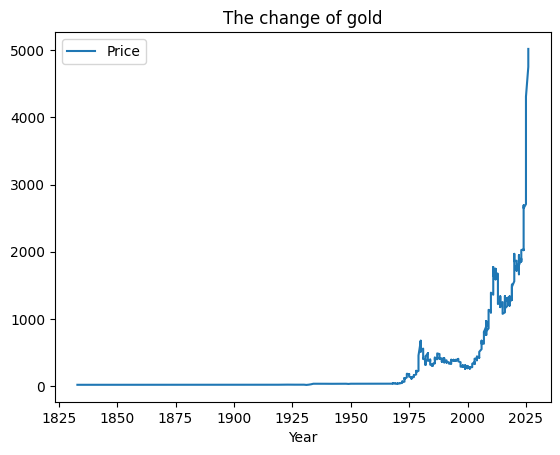

In [12]:
plot = df.plot(title='The change of gold', x = 'Year', y = 'Price')

Adding a Percentage column, to put the increase more into perspective, to better see a difference in relative return, by adding a percentage change in comparision to the previous month.

In [13]:
df['Percentage'] = df['Price'].pct_change() * 100
df

,Date,Price,Year,Month,Percentage
0,1833-01-01,18.93,1833,1,NaN
1,1833-02-01,18.93,1833,2,0.000000
2,1833-03-01,18.93,1833,3,0.000000
3,1833-04-01,18.93,1833,4,0.000000
4,1833-05-01,18.93,1833,5,0.000000
...,...,...,...,...,...
2313,2025-10-01,4058.33,2025,10,10.651147
2314,2025-11-01,4087.19,2025,11,0.711130
2315,2025-12-01,4309.23,2025,12,5.432583
2316,2026-01-01,4752.75,2026,1,10.292326


In the graph it seems like during the 1925s would have one of the biggest returns. Another time are after the 1970s, especially around 1978.

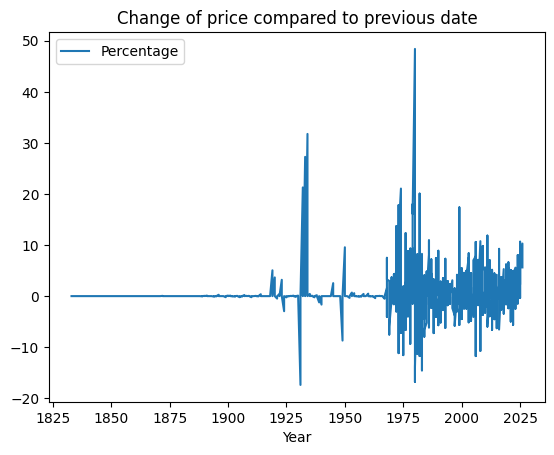

In [14]:
plot = df.plot(title='Change of price compared to previous date', x = 'Year', y = 'Percentage')

# Deeper analysis
**In the following code segments I added a column of YoY Percentage, which displays the change of percentage in gold price compared to the previous year, to better filter out volatilities.**

In [15]:
df['YoY Percentage'] = df['Price'].pct_change(periods = 12) * 100
df

,Date,Price,Year,Month,Percentage,YoY Percentage
0,1833-01-01,18.93,1833,1,NaN,NaN
1,1833-02-01,18.93,1833,2,0.000000,NaN
2,1833-03-01,18.93,1833,3,0.000000,NaN
3,1833-04-01,18.93,1833,4,0.000000,NaN
4,1833-05-01,18.93,1833,5,0.000000,NaN
...,...,...,...,...,...,...
2313,2025-10-01,4058.33,2025,10,10.651147,50.862800
2314,2025-11-01,4087.19,2025,11,0.711130,54.167845
2315,2025-12-01,4309.23,2025,12,5.432583,62.734657
2316,2026-01-01,4752.75,2026,1,10.292326,75.398293


We can see that our previous assumption is partially true, around the time of 1927/28 the return is going up, but not in a same sharp increase, especially compared to other periods. The highest return is during the 1970s, especially around 1977/78 and we can see how in recent time the price starts to rise.

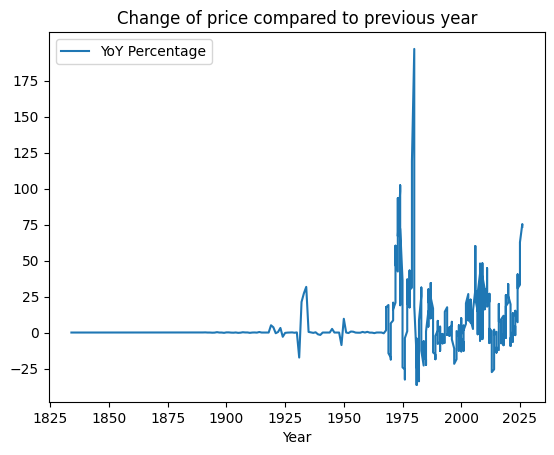

In [16]:
plot = df.plot(title='Change of price compared to previous year', x = 'Year', y = 'YoY Percentage')
plot.set_yticks(np.arange(-25, 200, 25));

# **Conclusion**
The analysis reveals that while the absolute price of gold is at an all-time high in 2025/2026, the most significant relative growth periods occurred in the late 1970s. This highlights the importance of looking at percentage changes (YoY) rather than just absolute numbers to understand true market volatility and investment potential.